<a href="https://colab.research.google.com/github/arjunnamburi/ml_death_overs_ipl/blob/main/notebooks/models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
DATA = '/content/drive/MyDrive/IPL PROJECT ALL DOCS/data/'
SEED = 42                      # fixed seed, so the bootstrap results are reproducible

df = pd.read_parquet(DATA + 'ipl_features.parquet')
with open(DATA + 'feature_list.json') as f:
    meta = json.load(f)
FEATURES, CAT_FEATURES, CLASSES = meta['features'], meta['categorical'], meta['classes']
K = len(CLASSES)               # 7 classes: 0, 1, 2, 3, 4, 6, Wicket

# Legal balls in train and validation only
d = df[(df['y'] >= 0) & df['split'].isin(['train', 'val'])].copy()
d['y'] = d['y'].astype(int)

TR = (d['split'] == 'train').values
VA = (d['split'] == 'val').values
DEATH = (d['match_phase'] == 'death').values

Mounted at /content/drive


In [2]:
print('1.', len(df), len(d))                                   # all deliveries vs our working rows
print('2.', d['split'].value_counts().to_dict())              # Expected: train 244269, val 15809
print('3.', sorted(d['innings'].unique()))                     # Expected: [1, 2]
print('4.', (TR & DEATH).sum(), (VA & DEATH).sum())            # Expected: 55634 3466
print('5.', d['match_phase'].unique().tolist())                # Expected: powerplay, middle, death
print('6.', CLASSES, K)                                        # Expected: ['0','1','2','3','4','6','Wicket'] 7
print('7.', d['y'].value_counts(normalize=True).sort_index().round(3).tolist())
print('8.', d['rain_affected'].sum())                          # Expected: 0

1. 295553 260078
2. {'train': 244269, 'val': 15809}
3. [np.int64(1), np.int64(2)]
4. 55634 3466
5. ['powerplay', 'middle', 'death']
6. ['0', '1', '2', '3', '4', '6', 'Wicket'] 7
7. [0.308, 0.398, 0.066, 0.003, 0.121, 0.053, 0.051]
8. 0


In [3]:
EPS = 1e-15
LOSS = {}       # per-ball log-losses, keyed by (model, split), for paired comparisons later
results = []    # the results table: one row per (model, split, slice), grows with every model

def per_ball_logloss(P, y):
    """-ln(probability given to the outcome that actually happened), one value per ball."""
    p_true = P[np.arange(len(y)), y]
    return -np.log(np.clip(p_true, EPS, 1))

def per_ball_brier(P, y):
    """Sum over the 7 classes of (p_c - o_c)^2, one value per ball."""
    O = np.zeros_like(P)
    O[np.arange(len(y)), y] = 1
    return ((P - O) ** 2).sum(axis=1)

def match_bootstrap(values, match_ids, B=2000, seed=SEED):
    """95% interval for the mean of per-ball values, resampling whole matches."""
    s = pd.DataFrame({'m': match_ids, 'v': values}).groupby('m')['v'].agg(['sum', 'count'])
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(s), size=(B, len(s)))          # B resamples, each a list of match positions
    means = s['sum'].values[idx].sum(axis=1) / s['count'].values[idx].sum(axis=1)
    return np.percentile(means, [2.5, 97.5])

def evaluate(name, P, rows, split_name, slices=('all', 'death')):
    """Score probabilities P (one row per ball in `rows`), keep the per-ball losses, add rows to the results table."""
    assert P.shape == (rows.sum(), K), 'one row of 7 probabilities per ball'
    assert np.allclose(P.sum(axis=1), 1), 'probabilities must sum to 1'
    assert (P > 0).all(), 'a probability of 0 makes log-loss infinite'
    y = d.loc[rows, 'y'].values
    m = d.loc[rows, 'match_id'].values
    death = DEATH[rows]
    ll, br = per_ball_logloss(P, y), per_ball_brier(P, y)
    LOSS[name, split_name] = pd.Series(ll, index=d.index[rows])
    results[:] = [r for r in results if (r['model'], r['split']) != (name, split_name)]   # rerun-safe
    for sl in slices:
        mask = death if sl == 'death' else np.ones(len(y), bool)
        lo, hi = match_bootstrap(ll[mask], m[mask])
        results.append(dict(model=name, split=split_name, slice=sl, balls=int(mask.sum()),
                            logloss=ll[mask].mean(), ll_low=lo, ll_high=hi, brier=br[mask].mean()))
    return pd.DataFrame(results).query('model == @name and split == @split_name').round(4)

def compare(a, b, split_name, sl='all'):
    """Mean log-loss of model a minus model b on the same balls, with a paired match-bootstrap interval.
    Negative means a is better."""
    diff = (LOSS[a, split_name] - LOSS[b, split_name]).dropna()    # only balls both models scored
    if sl == 'death':
        diff = diff[(d.loc[diff.index, 'match_phase'] == 'death').values]
    lo, hi = match_bootstrap(diff.values, d.loc[diff.index, 'match_id'].values)
    return pd.Series({'diff': diff.mean(), 'low': lo, 'high': hi, 'balls': len(diff)}).round(4)

def loss_by_class(name, split_name):
    """Which outcomes the log-loss comes from: share of balls, average loss, share of total loss."""
    ll = LOSS[name, split_name]
    t = pd.DataFrame({'cls': d.loc[ll.index, 'y'].values, 'll': ll.values}).groupby('cls')['ll'].agg(['count', 'mean', 'sum'])
    t.index = [CLASSES[i] for i in t.index]
    return pd.DataFrame({'share_of_balls': t['count'] / t['count'].sum(),
                         'avg_loss': t['mean'],
                         'share_of_loss': t['sum'] / t['sum'].sum()}).round(3)

In [4]:
yv = d.loc[VA, 'y'].values
U = np.full((VA.sum(), K), 1 / K)                     # uniform: 1/7 on every class
print('1.', per_ball_logloss(U, yv).mean().round(4), np.log(K).round(4))     # Expected: 1.9459 1.9459
print('2.', per_ball_brier(U, yv).mean().round(4), round(6 / 7, 4))         # Expected: 0.8571 0.8571
Perfect = np.full((VA.sum(), K), 1e-9); Perfect[np.arange(len(yv)), yv] = 1 - 6e-9
print('3.', per_ball_logloss(Perfect, yv).mean().round(4), per_ball_brier(Perfect, yv).mean().round(4))   # Expected: 0.0 0.0
evaluate('Uniform', U, VA, 'val')

1. 1.9459 1.9459
2. 0.8571 0.8571
3. 0.0 0.0


,model,split,slice,balls,logloss,ll_low,ll_high,brier
0,Uniform,val,all,15809,1.9459,1.9459,1.9459,0.8571
1,Uniform,val,death,3466,1.9459,1.9459,1.9459,0.8571


In [5]:
def fit_freq(y):
    """Share of each of the 7 classes in y."""
    return np.bincount(y, minlength=K) / len(y)

def predict_const(p, rows):
    """The same 7 probabilities for every ball in rows."""
    return np.tile(p, (rows.sum(), 1))

# B0: training class frequencies, predicted for every ball
p_b0 = fit_freq(d.loc[TR, 'y'].values)
print(pd.Series(p_b0, index=CLASSES).round(4))

evaluate('B0', predict_const(p_b0, TR), TR, 'train')
evaluate('B0', predict_const(p_b0, VA), VA, 'val')

# B0-death: frequencies from training death-over balls only, scored on validation death balls
p_b0d = fit_freq(d.loc[TR & DEATH, 'y'].values)
evaluate('B0-death', predict_const(p_b0d, VA & DEATH), VA & DEATH, 'val', slices=('death',))

pd.DataFrame(results).round(4)

0         0.3102
1         0.3982
2         0.0660
3         0.0032
4         0.1202
6         0.0513
Wicket    0.0510
dtype: float64


,model,split,slice,balls,logloss,ll_low,ll_high,brier
0,Uniform,val,all,15809,1.9459,1.9459,1.9459,0.8571
1,Uniform,val,death,3466,1.9459,1.9459,1.9459,0.8571
2,B0,train,all,244269,1.4862,1.4823,1.4901,0.7212
3,B0,train,death,55634,1.6378,1.6297,1.6457,0.7649
4,B0,val,all,15809,1.5391,1.5229,1.5557,0.7391
5,B0,val,death,3466,1.6682,1.6388,1.6985,0.7754
6,B0-death,val,death,3466,1.6124,1.5868,1.6378,0.7579


In [6]:
H_train = -(p_b0 * np.log(p_b0)).sum()
print('1.', p_b0.sum().round(6))                                       # Expected: 1.0
print('2.', H_train.round(4), LOSS['B0', 'train'].mean().round(4))     # Expected: equal, about 1.485
print('3.'); print(compare('B0-death', 'B0', 'val', 'death'))          # Expected: diff negative
print('4.'); print(loss_by_class('B0', 'val'))

1. 1.0
2. 1.4862 1.4862
3.
diff       -0.0558
low        -0.0652
high       -0.0458
balls    3466.0000
dtype: float64
4.
        share_of_balls  avg_loss  share_of_loss
0                0.270     1.171          0.205
1                0.399     0.921          0.239
2                0.059     2.718          0.105
3                0.002     5.749          0.006
4                0.139     2.119          0.191
6                0.079     2.970          0.153
Wicket           0.052     2.977          0.101


In [7]:
def entropy(p):
    """Log-loss of predicting the mix p on balls whose true mix is p."""
    return -(p * np.log(p)).sum()

# 2025's own mixes: a measurement only, never used as a model or to choose anything
p_val  = fit_freq(d.loc[VA, 'y'].values)
p_vald = fit_freq(d.loc[VA & DEATH, 'y'].values)

for label, p_tr, p_va, model in [('All balls', p_b0, p_val, 'B0'), ('Death balls', p_b0d, p_vald, 'B0-death')]:
    H_tr, H_va, score = entropy(p_tr), entropy(p_va), LOSS[model, 'val'].mean()
    print(f'{label} ({model})')
    print(f'  {"train entropy":<26}{H_tr:.4f}')
    print(f'  {"best constant for 2025":<26}{H_va:.4f}   2025 is harder: {H_va - H_tr:+.4f}')
    print(f'  {model + " on 2025":<26}{score:.4f}   stale mix:      {score - H_va:+.4f}')

drift = pd.DataFrame({'train': p_b0, '2025': p_val, 'train death': p_b0d, '2025 death': p_vald}, index=CLASSES)
drift['ratio all'] = drift['2025'] / drift['train']
drift['ratio death'] = drift['2025 death'] / drift['train death']
drift.round(3)

All balls (B0)
  train entropy             1.4862
  best constant for 2025    1.5277   2025 is harder: +0.0415
  B0 on 2025                1.5391   stale mix:      +0.0114
Death balls (B0-death)
  train entropy             1.5956
  best constant for 2025    1.6050   2025 is harder: +0.0094
  B0-death on 2025          1.6124   stale mix:      +0.0074


,train,2025,train death,2025 death,ratio all,ratio death
0,0.310,0.270,0.205,0.192,0.870,0.937
1,0.398,0.399,0.412,0.406,1.002,0.984
2,0.066,0.059,0.092,0.074,0.901,0.799
3,0.003,0.002,0.003,0.001,0.536,0.546
4,0.120,0.139,0.121,0.130,1.155,1.077
6,0.051,0.079,0.083,0.111,1.546,1.334
Wicket,0.051,0.052,0.084,0.086,1.020,1.029


In [8]:
# Leakage check: c_team_wickets must count wickets BEFORE the ball
nxt = df.groupby(['match_id', 'innings'])['c_team_wickets'].shift(-1)        # next delivery's count
on_wkt = (df['is_dismissal'] == 1) & nxt.notna()
print('1.', d['c_team_wickets'].max())                                        # Expected: 9, never 10
print('2.', ((nxt - df['c_team_wickets'])[on_wkt] == 1).mean().round(4))      # Expected: 1.0

# The 24 cells: phase x wickets fallen before the ball (bands) x innings
WKT_BAND = pd.cut(d['c_team_wickets'], bins=[-1, 2, 5, 7, 9], labels=['0-2', '3-5', '6-7', '8-9'])
d['cell'] = d['match_phase'].astype(str) + ' | ' + WKT_BAND.astype(str) + ' wkts | inn ' + d['innings'].astype(str)
ALL_CELLS = [f'{ph} | {w} wkts | inn {i}' for ph in ['powerplay', 'middle', 'death']
             for w in ['0-2', '3-5', '6-7', '8-9'] for i in [1, 2]]
print('3.', d['cell'].isin(ALL_CELLS).all(), d['cell'].nunique())             # Expected: True 24

1. 9
2. 1.0
3. True 21


In [9]:
print(sorted(set(ALL_CELLS) - set(d['cell'])))

['powerplay | 6-7 wkts | inn 1', 'powerplay | 8-9 wkts | inn 1', 'powerplay | 8-9 wkts | inn 2']


In [10]:
K_SHRINK = 100      # pseudo-balls of B0 added to every cell

def fit_b1(rows, k=K_SHRINK):
    """Each cell's class frequencies on `rows`, shrunk toward the overall frequencies of the same rows."""
    counts = (pd.crosstab(d.loc[rows, 'cell'], d.loc[rows, 'y'])
                .reindex(index=ALL_CELLS, columns=range(K), fill_value=0))
    prior = fit_freq(d.loc[rows, 'y'].values)
    n = counts.sum(axis=1).values[:, None]                          # balls per cell
    probs = np.where(n + k > 0, (counts.values + k * prior) / np.maximum(n + k, 1), prior)
    return pd.DataFrame(probs, index=ALL_CELLS, columns=CLASSES), counts.sum(axis=1)

def predict_b1(table, rows):
    """Look up each ball's cell and return that cell's 7 probabilities."""
    return table.loc[d.loc[rows, 'cell']].values

b1_table, b1_n = fit_b1(TR)
evaluate('B1', predict_b1(b1_table, TR), TR, 'train')
evaluate('B1', predict_b1(b1_table, VA), VA, 'val')

# The fitted table: balls per cell, and the probabilities that matter most at the death
cells = b1_table[['0', '4', '6', 'Wicket']].copy()
cells.insert(0, 'val balls', d.loc[VA, 'cell'].value_counts().reindex(ALL_CELLS, fill_value=0))
cells.insert(0, 'train balls', b1_n)
display(cells.round(3))

,train balls,val balls,0,4,6,Wicket
powerplay | 0-2 wkts | inn 1,36564,2359,0.433,0.160,0.035,0.038
powerplay | 0-2 wkts | inn 2,36037,2318,0.423,0.167,0.039,0.041
powerplay | 3-5 wkts | inn 1,1344,125,0.530,0.124,0.020,0.033
powerplay | 3-5 wkts | inn 2,1856,166,0.487,0.135,0.029,0.034
powerplay | 6-7 wkts | inn 1,0,0,0.310,0.120,0.051,0.051
powerplay | 6-7 wkts | inn 2,12,0,0.322,0.134,0.046,0.045
powerplay | 8-9 wkts | inn 1,0,0,0.310,0.120,0.051,0.051
powerplay | 8-9 wkts | inn 2,0,0,0.310,0.120,0.051,0.051
middle | 0-2 wkts | inn 1,32760,1979,0.247,0.098,0.055,0.043
middle | 0-2 wkts | inn 2,30057,1993,0.265,0.100,0.045,0.043


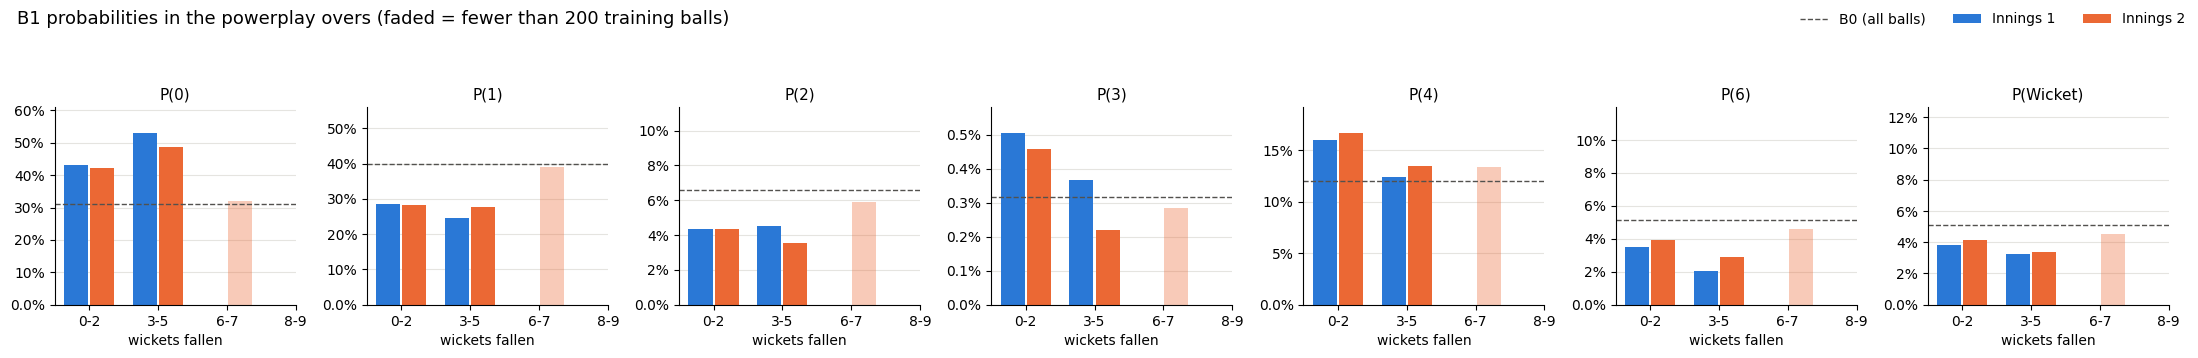

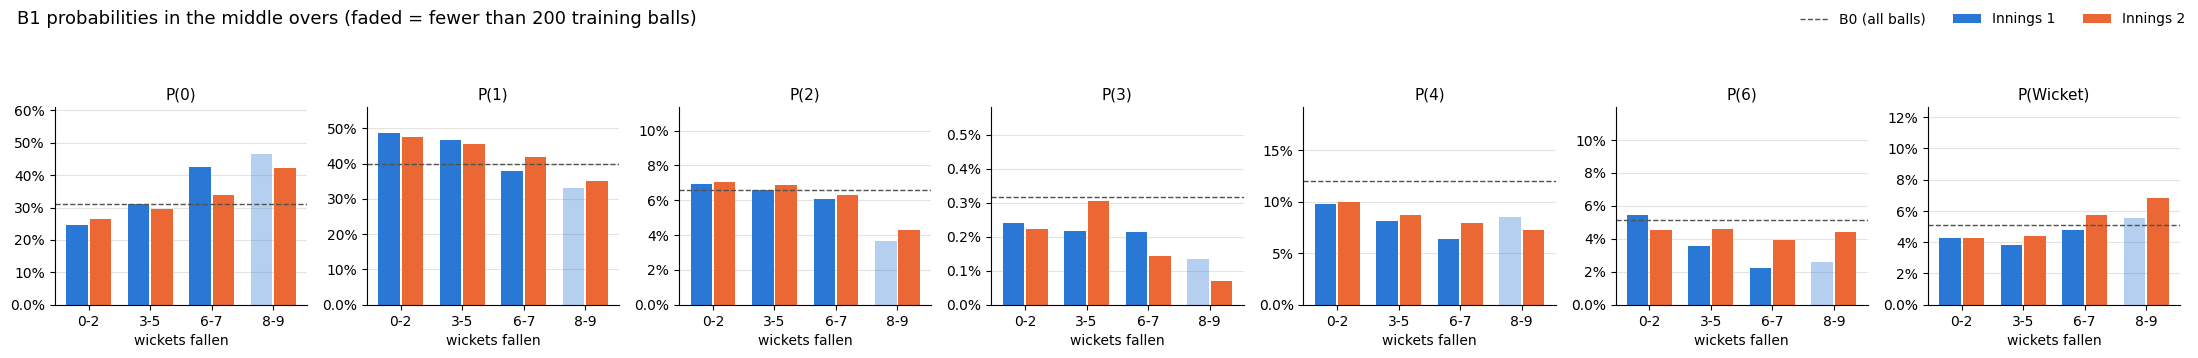

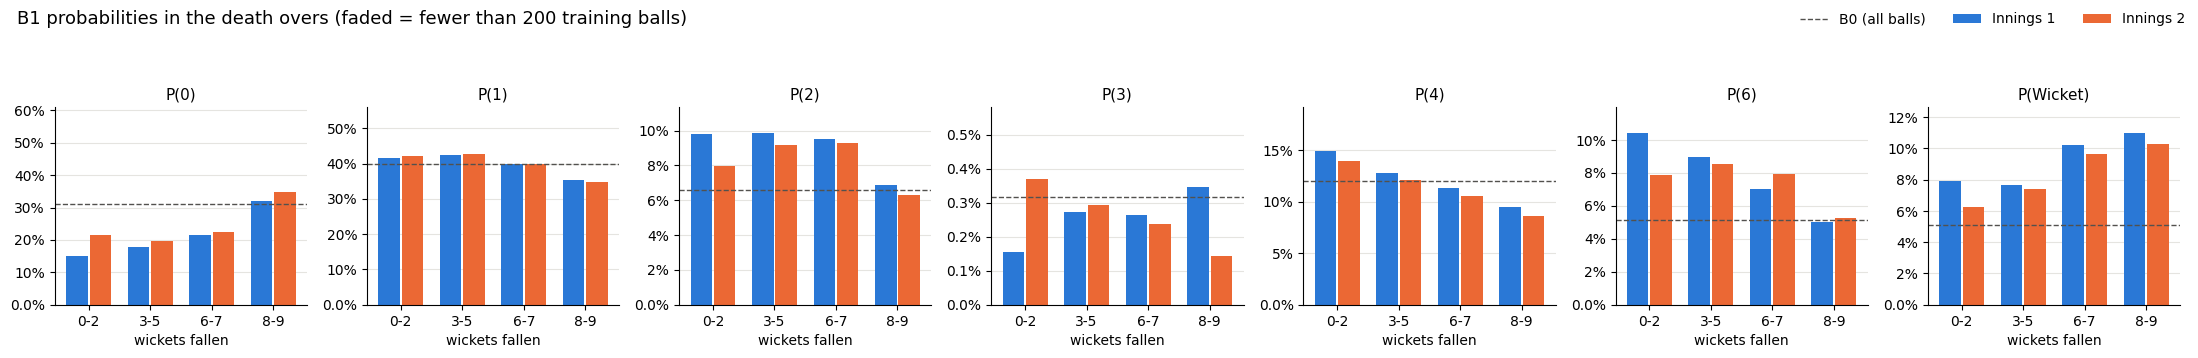

In [11]:
BANDS = ['0-2', '3-5', '6-7', '8-9']
INN_COLORS = {1: '#2a78d6', 2: '#eb6834'}      # innings 1 blue, innings 2 orange
THIN = 200                                     # cells with fewer training balls than this are drawn faded

# One y-scale per outcome, shared by all three phases, so the phases can be compared by eye
YMAX = {c: b1_table[c].max() * 1.15 for c in CLASSES}

def plot_phase(phase):
    fig, axes = plt.subplots(1, K, figsize=(22, 3.6), sharex=True)
    x = np.arange(len(BANDS))
    w = 0.38
    for ax, c in zip(axes, CLASSES):
        for j, inn in enumerate([1, 2]):
            keys = [f'{phase} | {b} wkts | inn {inn}' for b in BANDS]
            p = b1_table.loc[keys, c].values
            n = b1_n.loc[keys].values
            for xi, pi, ni in zip(x, p, n):
                if ni == 0:
                    continue                                   # empty cell: nothing to show
                ax.bar(xi + (j - 0.5) * w, pi, width=w * 0.92, color=INN_COLORS[inn],
                       alpha=1.0 if ni >= THIN else 0.35, label=f'Innings {inn}' if xi == 0 else None)
        ax.axhline(p_b0[CLASSES.index(c)], color='#52514e', lw=1, ls='--', label='B0 (all balls)')
        ax.set_title(f'P({c})', fontsize=11)
        ax.set_xticks(x, BANDS)
        ax.set_xlabel('wickets fallen')
        ax.set_ylim(0, YMAX[c])
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}' if v >= 0.01 else f'{v:.1%}'))
        ax.grid(axis='y', color='#e5e4e0', lw=0.8)
        ax.set_axisbelow(True)
        for s in ['top', 'right']:
            ax.spines[s].set_visible(False)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', ncol=3, frameon=False)
    fig.suptitle(f'B1 probabilities in the {phase} overs (faded = fewer than {THIN} training balls)',
                 x=0.01, ha='left', fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.9))
    plt.show()

for phase in ['powerplay', 'middle', 'death']:
    plot_phase(phase)

In [12]:
pd.DataFrame(results).round(4)

,model,split,slice,balls,logloss,ll_low,ll_high,brier
0,Uniform,val,all,15809,1.9459,1.9459,1.9459,0.8571
1,Uniform,val,death,3466,1.9459,1.9459,1.9459,0.8571
2,B0,train,all,244269,1.4862,1.4823,1.4901,0.7212
3,B0,train,death,55634,1.6378,1.6297,1.6457,0.7649
4,B0,val,all,15809,1.5391,1.5229,1.5557,0.7391
5,B0,val,death,3466,1.6682,1.6388,1.6985,0.7754
6,B0-death,val,death,3466,1.6124,1.5868,1.6378,0.7579
7,B1,train,all,244269,1.4496,1.4456,1.4535,0.7035
8,B1,train,death,55634,1.5867,1.5802,1.5928,0.7476
9,B1,val,all,15809,1.5119,1.4953,1.5287,0.7253


In [13]:
yv = d.loc[VA, 'y'].values
print('1. k, val all, val death, zero probabilities in table')
for k in [0, 10, 100, 1000]:
    t, _ = fit_b1(TR, k)
    ll = per_ball_logloss(predict_b1(t, VA), yv)
    print('  ', k, ll.mean().round(4), ll[DEATH[VA]].mean().round(4), int((t.values == 0).sum()))

print('2. B1 vs B0, all balls');           print(compare('B1', 'B0', 'val'))
print('3. B1 vs B0, death balls');         print(compare('B1', 'B0', 'val', 'death'))
print('4. B1 vs B0-death, death balls');   print(compare('B1', 'B0-death', 'val', 'death'))

1. k, val all, val death, zero probabilities in table
   0 1.514 1.6016 6
   10 1.5123 1.6016 0
   100 1.5119 1.6018 0
   1000 1.5119 1.6042 0
2. B1 vs B0, all balls
diff        -0.0272
low         -0.0309
high        -0.0231
balls    15809.0000
dtype: float64
3. B1 vs B0, death balls
diff       -0.0664
low        -0.0761
high       -0.0564
balls    3466.0000
dtype: float64
4. B1 vs B0-death, death balls
diff       -0.0106
low        -0.0168
high       -0.0052
balls    3466.0000
dtype: float64


In [14]:
# Where did the game change? Raw outcome rates (no shrinkage) in training vs 2025
SHOW = ['0', '2', '4', '6', 'Wicket']

def rates(rows, by):
    """Share of each outcome within each group of `by`, on `rows`."""
    t = pd.crosstab(d.loc[rows, by], d.loc[rows, 'y'], normalize='index')
    return t.reindex(columns=range(K), fill_value=0).set_axis(CLASSES, axis=1)[SHOW]

# 1. By phase: rates in %, and the change in percentage points
ph_tr, ph_va = rates(TR, 'match_phase'), rates(VA, 'match_phase')
by_phase = pd.concat({'train': ph_tr, '2025': ph_va, 'change': ph_va - ph_tr}, axis=1).swaplevel(axis=1)[SHOW]
print('1. Outcome rates by phase (%)')
display((by_phase * 100).round(1))

# 2. Where 2025's extra sixes came from: 2025 balls in the phase x (2025 six rate - train six rate)
n_ph = d.loc[VA, 'match_phase'].value_counts().reindex(ph_va.index)
extra = n_ph * (ph_va['6'] - ph_tr['6'])
print('2. Extra sixes in 2025 vs the training rate, by phase')
display(pd.DataFrame({'2025 balls': n_ph, 'extra sixes': extra.round(0), 'share of extra': (extra / extra.sum()).round(2)}))

# 3. By cell: six and wicket rates (%), cells with at least 200 balls in 2025
c_tr, c_va = rates(TR, 'cell'), rates(VA, 'cell')
by_cell = pd.DataFrame({
    '2025 balls': d.loc[VA, 'cell'].value_counts(),
    'six train': c_tr['6'] * 100, 'six 2025': c_va['6'] * 100, 'six x': c_va['6'] / c_tr['6'],
    'wkt train': c_tr['Wicket'] * 100, 'wkt 2025': c_va['Wicket'] * 100, 'wkt x': c_va['Wicket'] / c_tr['Wicket'],
}).reindex(ALL_CELLS)
print('3. Six and wicket rates by cell (cells with 200+ balls in 2025)')
display(by_cell[by_cell['2025 balls'] >= 200].round(2))

1. Outcome rates by phase (%)


0                  2                 4                  6  \
            train  2025 change train 2025 change train  2025 change train   
match_phase                                                                 
powerplay    43.2  36.5   -6.7   4.3  4.9    0.6  16.2  18.5    2.3   3.7   
middle       28.0  24.3   -3.7   6.8  6.0   -0.9   9.2  11.2    2.0   4.6   
death        20.5  19.2   -1.3   9.2  7.4   -1.9  12.1  13.0    0.9   8.3   

                         Wicket              
             2025 change  train 2025 change  
match_phase                                  
powerplay     7.2    3.5    3.9  3.9    0.0  
middle        7.0    2.4    4.3  4.4    0.2  
death        11.1    2.8    8.4  8.6    0.2

2. Extra sixes in 2025 vs the training rate, by phase


,2025 balls,extra sixes,share of extra
match_phase,,,
powerplay,4968,175.0,0.39
middle,7375,177.0,0.40
death,3466,96.0,0.21


3. Six and wicket rates by cell (cells with 200+ balls in 2025)


,2025 balls,six train,six 2025,six x,wkt train,wkt 2025,wkt x
cell,,,,,,,
powerplay | 0-2 wkts | inn 1,2359.0,3.49,7.12,2.04,3.82,3.82,1.00
powerplay | 0-2 wkts | inn 2,2318.0,3.94,7.42,1.88,4.12,4.14,1.01
middle | 0-2 wkts | inn 1,1979.0,5.47,7.02,1.28,4.26,4.70,1.10
middle | 0-2 wkts | inn 2,1993.0,4.53,8.08,1.78,4.27,4.21,0.99
middle | 3-5 wkts | inn 1,1571.0,3.56,5.73,1.61,3.83,4.33,1.13
middle | 3-5 wkts | inn 2,1479.0,4.57,6.90,1.51,4.39,4.12,0.94
death | 0-2 wkts | inn 1,238.0,10.55,14.71,1.39,7.98,8.40,1.05
death | 0-2 wkts | inn 2,239.0,7.99,11.30,1.41,6.28,4.60,0.73
death | 3-5 wkts | inn 1,1126.0,9.01,12.61,1.40,7.68,7.90,1.03


,matches,balls,sixes,sixes per match,six % of balls,powerplay six %,middle six %,death six %
year,,,,,,,,
2008,53,12043,572,10.79,4.75,3.09,4.50,7.72
2009,52,12142,445,8.56,3.66,3.42,2.75,5.83
2010,59,13709,572,9.69,4.17,2.87,3.73,6.83
2011,68,15642,610,8.97,3.90,2.41,3.75,6.29
2012,73,17069,719,9.85,4.21,3.01,3.67,6.90
2013,74,17282,648,8.76,3.75,1.90,3.11,7.50
2014,57,13269,687,12.05,5.18,3.27,4.73,8.67
2015,53,12363,630,11.89,5.10,3.20,4.49,8.81
2016,56,12936,606,10.82,4.68,3.22,3.95,8.26


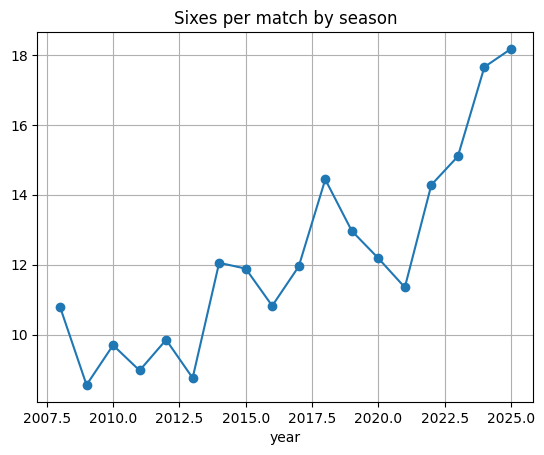

In [26]:
# Sixes per match and six rate by season (train + 2025 only; 2026 stays unseen)
SIX = CLASSES.index('6')
s = d.assign(six=(d['y'] == SIX))
by_season = s.groupby('year').agg(matches=('match_id', 'nunique'), balls=('six', 'size'), sixes=('six', 'sum'))
by_season['sixes per match'] = by_season['sixes'] / by_season['matches']
by_season['six % of balls'] = 100 * by_season['sixes'] / by_season['balls']

# Same six rate, split by phase
by_phase = 100 * s.pivot_table(index='year', columns='match_phase', values='six', aggfunc='mean', observed=True)
by_phase.columns = [f'{p} six %' for p in by_phase.columns]

display(by_season.join(by_phase).round(2))
by_season['sixes per match'].plot(marker='o', title='Sixes per match by season', grid=True);

1. All balls


,2025 actual,B0,B1
0,26.99,31.02,31.33
1,39.88,39.82,39.70
2,5.95,6.60,6.54
3,0.17,0.32,0.32
4,13.88,12.02,12.00
6,7.93,5.13,5.05
Wicket,5.20,5.10,5.05


2. Death balls


,2025 actual,B0,B0-death,B1
0,19.22,31.02,20.52,20.75
1,40.57,39.82,41.22,41.17
2,7.39,6.60,9.24,9.17
3,0.14,0.32,0.26,0.27
4,13.01,12.02,12.08,12.11
6,11.05,5.13,8.28,8.18
Wicket,8.63,5.10,8.39,8.34


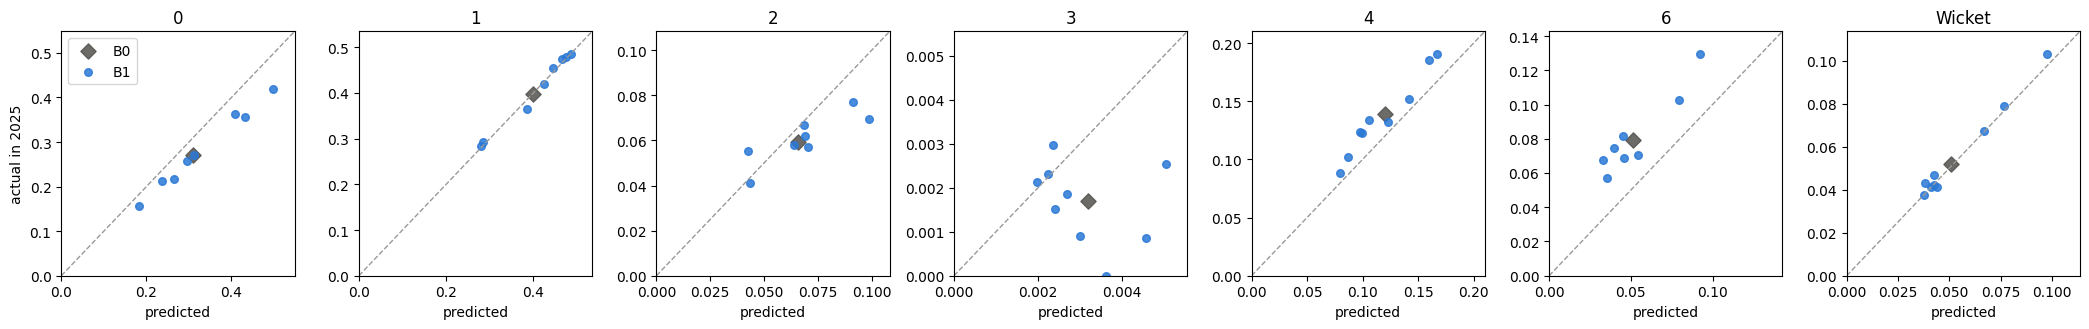

In [27]:
# Calibration on 2025: when a model says p%, does it happen p% of the time?
import matplotlib.pyplot as plt

def reliability(P, rows, bins=10):
    """Per class: balls grouped by predicted probability (quantile bins), mean prediction vs actual frequency."""
    y = d.loc[rows, 'y'].values
    out = []
    for c in range(K):
        b = pd.qcut(P[:, c], q=bins, duplicates='drop') if np.ptp(P[:, c]) > 0 else np.zeros(len(y))
        t = (pd.DataFrame({'pred': P[:, c], 'hit': y == c, 'bin': b})
               .groupby('bin', observed=True)
               .agg(pred=('pred', 'mean'), actual=('hit', 'mean'), balls=('hit', 'size')))
        out.append(t.assign(cls=CLASSES[c]))
    return pd.concat(out, ignore_index=True)

P_b0_val, P_b1_val = predict_const(p_b0, VA), predict_b1(b1_table, VA)
yv, dv = d.loc[VA, 'y'].values, DEATH[VA]

# 1. Average predicted vs actual, per class (%): all balls, then death balls
def avg_table(preds, mask):
    t = pd.DataFrame({'2025 actual': np.bincount(yv[mask], minlength=K) / mask.sum()}, index=CLASSES)
    for name, P in preds.items():
        t[name] = P[mask].mean(axis=0)
    return (100 * t).round(2)

print('1. All balls'); display(avg_table({'B0': P_b0_val, 'B1': P_b1_val}, np.ones(len(yv), bool)))
print('2. Death balls'); display(avg_table({'B0': P_b0_val, 'B0-death': predict_const(p_b0d, VA), 'B1': P_b1_val}, dv))

# 3. Reliability curves: one panel per class, dashed line = perfect calibration
rel = {'B0': reliability(P_b0_val, VA), 'B1': reliability(P_b1_val, VA)}
style = {'B0': dict(color='#52514e', marker='D', s=60), 'B1': dict(color='#2a78d6', marker='o', s=30)}
fig, axes = plt.subplots(1, K, figsize=(21, 3.4))
for ax, c in zip(axes, CLASSES):
    hi = 0
    for name, r in rel.items():
        t = r[r['cls'] == c]
        ax.scatter(t['pred'], t['actual'], label=name, alpha=0.85, **style[name])
        hi = max(hi, t['pred'].max(), t['actual'].max())
    hi *= 1.1
    ax.plot([0, hi], [0, hi], ls='--', color='#999999', lw=1)
    ax.set(xlim=(0, hi), ylim=(0, hi), title=c, xlabel='predicted')
axes[0].set_ylabel('actual in 2025'); axes[0].legend()
plt.tight_layout(); plt.show()

In [28]:
# Save the results table, the fitted baselines, and B0/B1 predictions on 2025
import os
OUT = '/content/drive/MyDrive/IPL PROJECT ALL DOCS/results/'
os.makedirs(OUT, exist_ok=True)

# 1. Results table: every model, split and slice scored so far
pd.DataFrame(results).to_csv(OUT + 'results.csv', index=False)

# 2. The fitted baselines themselves: B0 and B0-death frequencies, and B1's table with its training balls
pd.DataFrame({'B0': p_b0, 'B0-death': p_b0d}, index=CLASSES).to_csv(OUT + 'b0_freqs.csv')
b1_table.assign(train_balls=b1_n).to_csv(OUT + 'b1_table.csv')

# 3. Per-ball 2025 predictions; the index matches the dataset rows, so they join back later
preds = d.loc[VA, ['match_id', 'match_phase', 'y']].copy()
for name, P in {'B0': P_b0_val, 'B1': P_b1_val}.items():
    preds[[f'{name} {c}' for c in CLASSES]] = P
preds.to_parquet(OUT + 'val_preds_b0_b1.parquet')

# Read back to check
print(pd.read_csv(OUT + 'results.csv').shape, pd.read_parquet(OUT + 'val_preds_b0_b1.parquet').shape)
print(os.listdir(OUT))

(11, 8) (15809, 17)
['results.csv', 'b0_freqs.csv', 'b1_table.csv', 'val_preds_b0_b1.parquet']
